# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [2]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_5144/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [3]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [4]:
# Load training data
genomic_file = pd.read_csv("WHO-UCN-TB-2023.7-eng_genomic_coordinates.txt", sep="\t")

# Let's take a look at the data
print("Shape of the genomic file:", genomic_file.shape)
print(np.unique(genomic_file['variant']))
genomic_file.head()

Shape of the genomic file: (144964, 5)
['PPE35_c.-108A>G' 'PPE35_c.-110G>A' 'PPE35_c.-112T>C' ...
 'whiB7_p.Val6Phe' 'whiB7_p.Val91Gly' 'whiB7_p.Val91Ile']


,variant,chromosome,position,reference_nucleotide,alternative_nucleotide
0,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CA
1,dnaA_p.Asp3Ala,NC_000962.3,8,A,C
2,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CC
3,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CG
4,dnaA_p.Asp4His,NC_000962.3,10,G,C


In [5]:
merged_file = master_file.merge(
    genomic_file[["variant", "chromosome", "position", "reference_nucleotide", "alternative_nucleotide"]],
    on="variant",
    how="left"
)
merged_file.head()

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,chromosome,position,reference_nucleotide,alternative_nucleotide
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2064627.0,C,T
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2063685.0,C,T
2,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2063685.0,CAA,TAG
3,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2064624.0,G,C
4,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2063658.0,TAATCGA,CAACCGC


In [6]:
# check distribution of WHO grades
print(merged_file["gene"].value_counts().sort_index())
print(len(merged_file["gene"].unique()))
print(merged_file["gene"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

gene
PPE35      1977
Rv0010c    1255
Rv0565c    1204
Rv0678     2707
Rv1129c    5016
           ... 
tlyA       2002
tsnR        331
ubiA       1026
whiB6      3792
whiB7      1107
Name: count, Length: 65, dtype: int64
65
gene
PPE35      0.009721
Rv0010c    0.006171
Rv0565c    0.005920
Rv0678     0.013310
Rv1129c    0.024664
             ...   
tlyA       0.009844
tsnR       0.001628
ubiA       0.005045
whiB6      0.018645
whiB7      0.005443
Name: proportion, Length: 65, dtype: float64


In [7]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models
keep_columns = ['mutation', 'drug','gene','FINAL CONFIDENCE GRADING', "variant", "chromosome", "position", "reference_nucleotide", "alternative_nucleotide"]
merged_file_clean = merged_file.copy()
merged_file_clean = merged_file_clean[keep_columns]

In [8]:
# check distribution of WHO grades
print(merged_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(merged_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                   10124
2) Assoc w R - Interim         18888
3) Uncertain significance     143603
4) Not assoc w R - Interim     28632
5) Not assoc w R                2129
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.049780
2) Assoc w R - Interim        0.092872
3) Uncertain significance     0.706096
4) Not assoc w R - Interim    0.140784
5) Not assoc w R              0.010468
Name: proportion, dtype: float64


In [9]:
# Drop the uncertain resistance
df = merged_file.copy()
df = df[df['FINAL CONFIDENCE GRADING'] != '3) Uncertain significance']

# check distribution of WHO grades
print(df["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(df["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index())

df["FINAL CONFIDENCE GRADING"] = (
    df["FINAL CONFIDENCE GRADING"]
    .astype(str)
    .str.strip()
)

def make_binary_label(data):
    if "1) Assoc w R" in data or "2) Assoc w R - Interim" in data:
        return 1
    elif "4) Not assoc w R - Interim" in data or "5) Not assoc w R" in data:
        return 0
    return None

df["resistant"] = df["FINAL CONFIDENCE GRADING"].apply(make_binary_label)
df_model = df.dropna(subset=["resistant"]).copy()

print(df_model["resistant"].value_counts())

df_model = df_model.drop(columns=["FINAL CONFIDENCE GRADING"])


FINAL CONFIDENCE GRADING
1) Assoc w R                  10124
2) Assoc w R - Interim        18888
4) Not assoc w R - Interim    28632
5) Not assoc w R               2129
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.169374
2) Assoc w R - Interim        0.315996
4) Not assoc w R - Interim    0.479012
5) Not assoc w R              0.035618
Name: proportion, dtype: float64
resistant
0    30761
1    29012
Name: count, dtype: int64


In [ ]:


import pandas as pd
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

df_model["gene"] = df_model["gene"].str.strip()
df_model["mutation"] = df_model["mutation"].str.strip()


# keep only necessary columns
model_df = df_model[[
    "gene",
    "mutation",
    "drug",
    "resistant",
    "variant",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_5144/1550562639.py:180: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


num features: 129
mutation
drug
resistant
variant
chromosome
position
reference_nucleotide
alternative_nucleotide
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertain
re

In [11]:
one_hot_copy = one_hot_df.copy()
one_hot_copy = one_hot_df.drop(columns=["mutation", "variant", "chromosome"])
one_hot_df = one_hot_df.loc[:, ~one_hot_df.columns.duplicated()]
print(one_hot_df.shape)

(59773, 128)


In [12]:
# check distribution of WHO grades
print(one_hot_copy["resistant"].value_counts().sort_index())
print(one_hot_copy["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    30761
1    29012
Name: count, dtype: int64
resistant
0    0.51463
1    0.48537
Name: proportion, dtype: float64


In [13]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=256)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((256, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = one_hot_copy.merge(TB_drugs, on="drug", how="left")
final_data.head()

,drug,resistant,position,reference_nucleotide,alternative_nucleotide,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,Amikacin,0,2064627.0,C,T,102.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,Amikacin,0,2063685.0,C,T,1044.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,Amikacin,0,2063685.0,CAA,TAG,1044.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,Amikacin,0,2064624.0,G,C,105.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,Amikacin,0,2063658.0,TAATCGA,CAACCGC,1065.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [14]:
ml_data = final_data.copy()

#keep track of mapping for later
lookup_drugs = dict(enumerate(ml_data["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

ml_data["drug"] = ml_data["drug"].astype("category").cat.codes
ml_data.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,drug,resistant,position,reference_nucleotide,alternative_nucleotide,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0,0,2064627.0,C,T,102.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0,0,2063685.0,C,T,1044.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,0,0,2063685.0,CAA,TAG,1044.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0,0,2064624.0,G,C,105.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0,0,2063658.0,TAATCGA,CAACCGC,1065.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [15]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(ml_data["fingerprint"].tolist(), index=one_hot_copy.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([ml_data.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
print(final_ml.shape)
final_ml.head()

(105827, 382)


,drug,resistant,position,reference_nucleotide,alternative_nucleotide,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,0.0,0.0,2064627.0,C,T,102.0,0.0,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,2063685.0,C,T,1044.0,0.0,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,2063685.0,CAA,TAG,1044.0,0.0,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,2064624.0,G,C,105.0,0.0,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,2063658.0,TAATCGA,CAACCGC,1065.0,0.0,0.0,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [16]:
gene_cols = [c for c in final_ml.columns if c.startswith("gene_")]
rare = [c for c in gene_cols if final_ml[c].sum() < 10]

final_ml = final_ml.drop(columns=rare)
final_ml["ref_len"] = final_ml["reference_nucleotide"].astype(str).str.len()
final_ml["alt_len"] = final_ml["alternative_nucleotide"].astype(str).str.len()

final_ml["ref_base"] = final_ml["reference_nucleotide"].where(
    final_ml["ref_len"] == 1, "LONG"
)
final_ml["alt_base"] = final_ml["alternative_nucleotide"].where(
    final_ml["alt_len"] == 1, "LONG"
)
final_ml = final_ml.drop(
    columns=["reference_nucleotide", "alternative_nucleotide"],
    errors="ignore"
)

final_ml = pd.get_dummies(final_ml, columns=["ref_base", "alt_base"])
final_ml.head()

,drug,resistant,position,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.0,0.0,2064627.0,102.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,0.0,0.0,2063685.0,1044.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,0.0,0.0,2063685.0,1044.0,0.0,0.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,0.0,0.0,2064624.0,105.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
4,0.0,0.0,2063658.0,1065.0,0.0,0.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False


In [17]:
for prefix in ["gene_", "fp_", "ref_", "alt_", "mut_type_", "drug_", "alternative_", "reference_"]:
    cols = [c for c in final_ml.columns if c.startswith(prefix)]
    print(prefix, len(cols))

gene_ 65
fp_ 256
ref_ 27
alt_ 27
mut_type_ 11
drug_ 0
alternative_ 0
reference_ 0


In [18]:
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0.0    30761
1.0    29012
Name: count, dtype: int64
resistant
0.0    0.51463
1.0    0.48537
Name: proportion, dtype: float64


In [19]:
final_ml = final_ml.dropna(subset=["resistant"]).copy()
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue
final_ml.head()

resistant
0.0    30761
1.0    29012
Name: count, dtype: int64
resistant
0.0    0.51463
1.0    0.48537
Name: proportion, dtype: float64


,drug,resistant,position,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.0,0.0,2064627.0,102.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,0.0,0.0,2063685.0,1044.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,0.0,0.0,2063685.0,1044.0,0.0,0.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,0.0,0.0,2064624.0,105.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
4,0.0,0.0,2063658.0,1065.0,0.0,0.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False


##### NOW WE CAN START TESTING MODELS #####

In [20]:
# let's run a random train test split first
X_baseline = final_ml.drop(columns=["resistant"])
y_baseline = final_ml["resistant"]
print(y_baseline.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline)

# scale the data
scaler = StandardScaler()
XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

# convert back to dataframe
XS_train = pd.DataFrame(XS_train, columns=X_baseline.columns)
XS_test = pd.DataFrame(XS_test, columns=X_baseline.columns)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(XS_train, y_train)


0


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6152
         1.0       1.00      1.00      1.00      5803

    accuracy                           1.00     11955
   macro avg       1.00      1.00      1.00     11955
weighted avg       1.00      1.00      1.00     11955

[[6147    5]
 [   7 5796]]


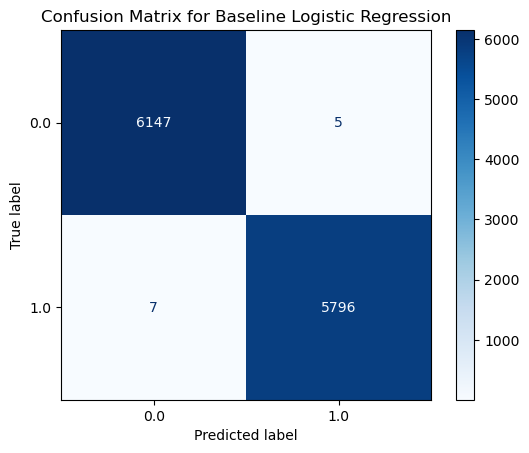

In [22]:
# plot the confusion matrix for the baseline model
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Baseline Logistic Regression")
plt.show()

In [23]:
holdout_drugs = [0.0, 8.0, 2.0]
train_df_holdout = final_ml[~final_ml["drug"].isin(holdout_drugs)].copy()
train_df_holdout = train_df_holdout.dropna()
test_df_holdout  = final_ml[final_ml["drug"].isin(holdout_drugs)].copy()
test_df_holdout = test_df_holdout.dropna()

In [24]:
X_train_holdout2 = train_df_holdout.drop(columns=["resistant", "drug"])
y_train_holdout2 = train_df_holdout["resistant"]
X_test_holdout2 = test_df_holdout.drop(columns=["resistant", "drug"])
y_test_holdout2 = test_df_holdout["resistant"]

print(f"Training set shape: {X_train_holdout2.shape}")
print(f"Holdout set shape: {X_test_holdout2.shape}")

print("Train:")
print(y_train_holdout2.value_counts())

print("\nTest:")
print(y_test_holdout2.value_counts())

Training set shape: (8184, 390)
Holdout set shape: (622, 390)
Train:
resistant
0.0    7309
1.0     875
Name: count, dtype: int64

Test:
resistant
0.0    544
1.0     78
Name: count, dtype: int64


In [25]:
# first remove any columns with inf values, then fill any remaining nan values with the median of each column
# scale the data
scaler = StandardScaler()
XS_train_holdout2 = scaler.fit_transform(X_train_holdout2)
XS_test_holdout2 = scaler.transform(X_test_holdout2)

# convert back to dataframe
XS_train_holdout2 = pd.DataFrame(XS_train_holdout2, columns=X_train_holdout2.columns)
XS_test_holdout2 = pd.DataFrame(XS_test_holdout2, columns=X_train_holdout2.columns)

# Run a logistic regression model as a baseline
baseline_model_holdout2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model_holdout2.fit(XS_train_holdout2, y_train_holdout2)
y_prob_baseline_holdout2 = baseline_model_holdout2.predict_proba(XS_test_holdout2)[:, 1]
y_pred_baseline_holdout2 = (y_prob_baseline_holdout2 > 0.6).astype(int)
print("Classification Report for Baseline Logistic Regression Removing 2 drugs:")
print(classification_report(y_test_holdout2, y_pred_baseline_holdout2))

Classification Report for Baseline Logistic Regression Removing 2 drugs:
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95       544
         1.0       0.60      1.00      0.75        78

    accuracy                           0.91       622
   macro avg       0.80      0.95      0.85       622
weighted avg       0.95      0.91      0.92       622



0.9512867647058824


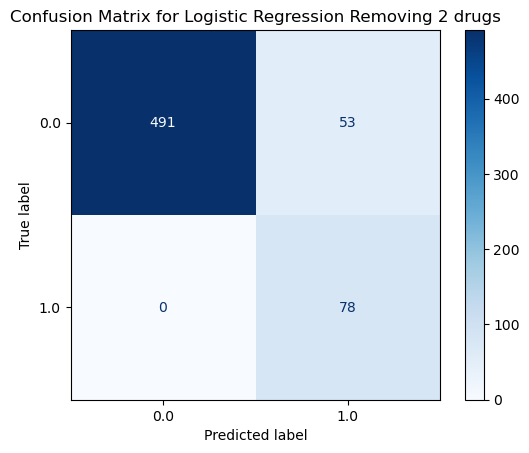

In [26]:
# check the balanced accuracy
balanced_accuracy_holdout2 = balanced_accuracy_score(y_test_holdout2, y_pred_baseline_holdout2)
print(balanced_accuracy_holdout2)

# plot the confusion matrix for the baseline model
cm_holdout = confusion_matrix(y_test_holdout2, y_pred_baseline_holdout2, labels=baseline_model_holdout2.classes_)
disp_holdout = ConfusionMatrixDisplay(confusion_matrix=cm_holdout, display_labels=baseline_model_holdout2.classes_)
disp_holdout.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Removing 2 drugs")
plt.show()

In [27]:
# perform random forest again
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_holdout2, y_train_holdout2)
y_pred_rf = rf.predict(X_test_holdout2)

print(classification_report(y_test_holdout2, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       544
         1.0       0.96      1.00      0.98        78

    accuracy                           1.00       622
   macro avg       0.98      1.00      0.99       622
weighted avg       1.00      1.00      1.00       622



0.9972426470588236


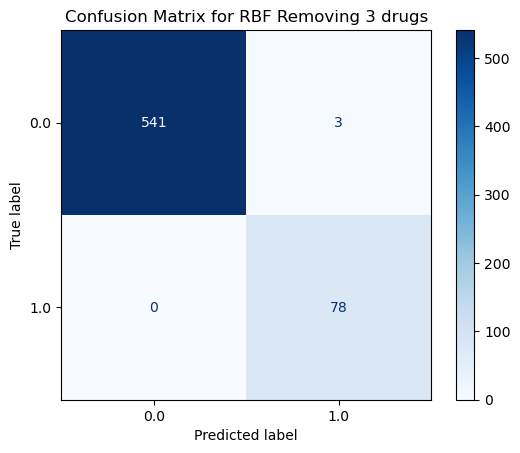

In [28]:
# check the balanced accuracy
balanced_accuracy_rbf = balanced_accuracy_score(y_test_holdout2, y_pred_rf)
print(balanced_accuracy_rbf)

# plot the confusion matrix for the baseline model
cm_holdout = confusion_matrix(y_test_holdout2, y_pred_rf, labels=baseline_model_holdout2.classes_)
disp_holdout = ConfusionMatrixDisplay(confusion_matrix=cm_holdout, display_labels=baseline_model_holdout2.classes_)
disp_holdout.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for RBF Removing 3 drugs")
plt.show()

In [29]:
importances = pd.Series(rf.feature_importances_, index=XS_train_holdout2.columns)
print(importances.sort_values(ascending=False).head(20))

mut_type_SNV           0.193484
position               0.122317
position               0.108427
mut_type_frameshift    0.054262
mut_type_missense      0.045301
ref_C                  0.040596
gene_gid               0.037351
alt_T                  0.026866
alt_len                0.024897
ref_len                0.023383
gene_ethA              0.021942
alt_C                  0.020794
alt_A                  0.019727
ref_G                  0.016846
alt_G                  0.011277
gene_rpoB              0.007799
ref_L                  0.007691
ref_T                  0.007193
alt_base_LONG          0.006579
ref_base_LONG          0.006069
dtype: float64
